<div class="alert alert-block alert-info" style="margin-top: 20px">
    

__Ms.MRUNALINI (Data Science Trainer)__
📧 mrunalini0107@gmail.com
📍 Mumbai–400095

<div class="alert alert-block alert-info" style="margin-top: 20px">

## 📘 Simulation of Statistical Models - MIXED EFFECT MODELS

### 📘 MIXED EFFECT MODELS
### 📌 Random-Effect ANCOVA (Repeated Measures Design)
🔹 Mixed Model Equation: $Y_{ij}​ = (β_0​+u_{0j}​)+(β_1​+u_{1j}​)Epo + ε_{ij}$​

where
* $u_{0j}$ = random intercept
* $u_{1j}$ = random slope
* $ε_{ij} ∼ N(0,σ^2)$​


#### 🔹 STUDY DESIGN

* 20 Subjects (10 Male, 10 Female)
* Each subject receives 6 Epo concentrations (0–5)
* Total observations = 20 × 6 = 120
* Fixed effects: Gender, Epo, Gender×Epo
* Random effects: Subject (intercept and/or slope)



####  📌 PART 1: DEFINE FIXED EFFECT STRUCTURE

In [2]:
# Gender factor (2 levels, each repeated 60 times)
Gender <- gl(2, 60, labels = c("Male", "Female"))

# Numerical representation for intercept (baseline power)
Gender_N <- rep(c(8, 10), each = 60)

# Epo dosage (0 to 5), repeated for 20 subjects
Epo <- rep(c(0,1,2,3,4,5), times = 20)

# Gender-specific slope (interaction term)
Gender_Int <- rep(c(1, 2), each = 60)


#### 📌 PART 2: CREATE RANDOM SUBJECT EFFECT (Intercept)

In [3]:
# 20 subjects, each measured 6 times
Subject <- gl(20, 6, labels = LETTERS[1:20])

set.seed(568)

# Random intercept effect per subject ~ N(0, 0.5²)
Random_Ef <- rep(rnorm(20, 0, 0.5), each = 6)

data.frame(Subject, Random_Ef)


Subject,Random_Ef
<fct>,<dbl>
A,-0.0317736
A,-0.0317736
A,-0.0317736
A,-0.0317736
A,-0.0317736
A,-0.0317736
B,0.7195121
B,0.7195121
B,0.7195121


🔎 Interpretation:

Each subject has their own deviation from the population intercept.

#### 📌 PART 3: FIXED EFFECT ONLY (NO RANDOM EFFECT)

`geom_smooth()` using formula = 'y ~ x'


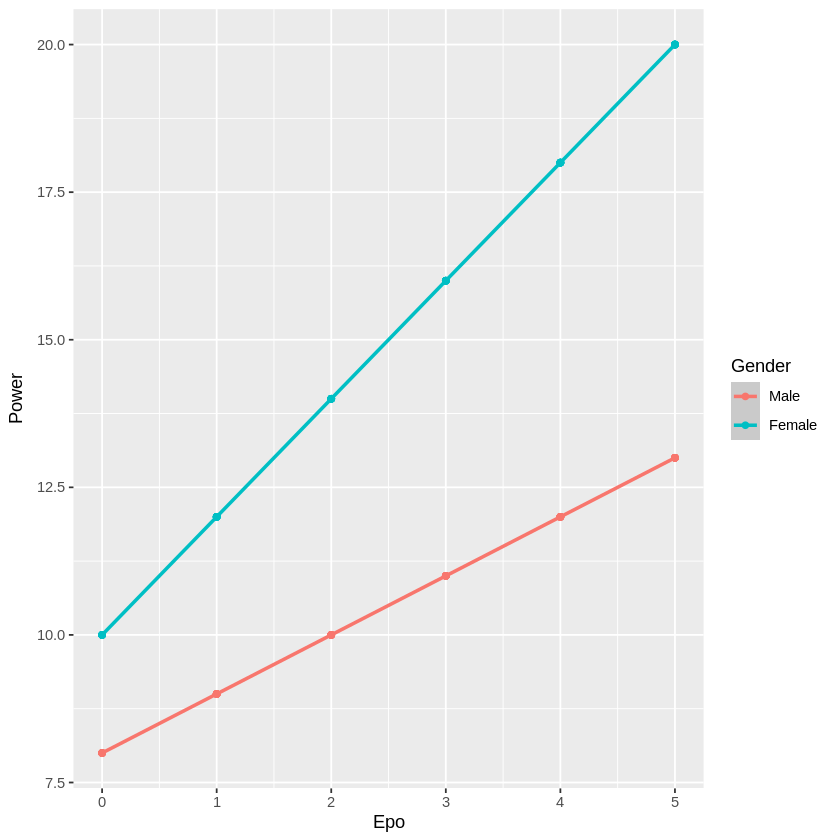

In [4]:
# Load ggplot2
library(ggplot2)

# Create variables
Power <- Gender_N + Gender_Int * Epo

# Build data frame
RANCOVA1a <- data.frame(Power, Gender, Epo, Subject)

# Plot
ggplot(RANCOVA1a, aes(x = Epo, y = Power, colour = Gender)) +
  geom_smooth(method = "lm") +
  geom_point()


📊 Interpretation

* Lines differ by gender.
* No subject variability.
* Pure fixed-effect ANCOVA model:

$Y_{ij}​ = β_0 ​+ β_1 ​Gender + β_2 ​Epo + β_3​(Gender × Epo)$

#### 📌 PART 4: ADD RESIDUAL ERROR (STILL FIXED MODEL)

`geom_smooth()` using formula = 'y ~ x'


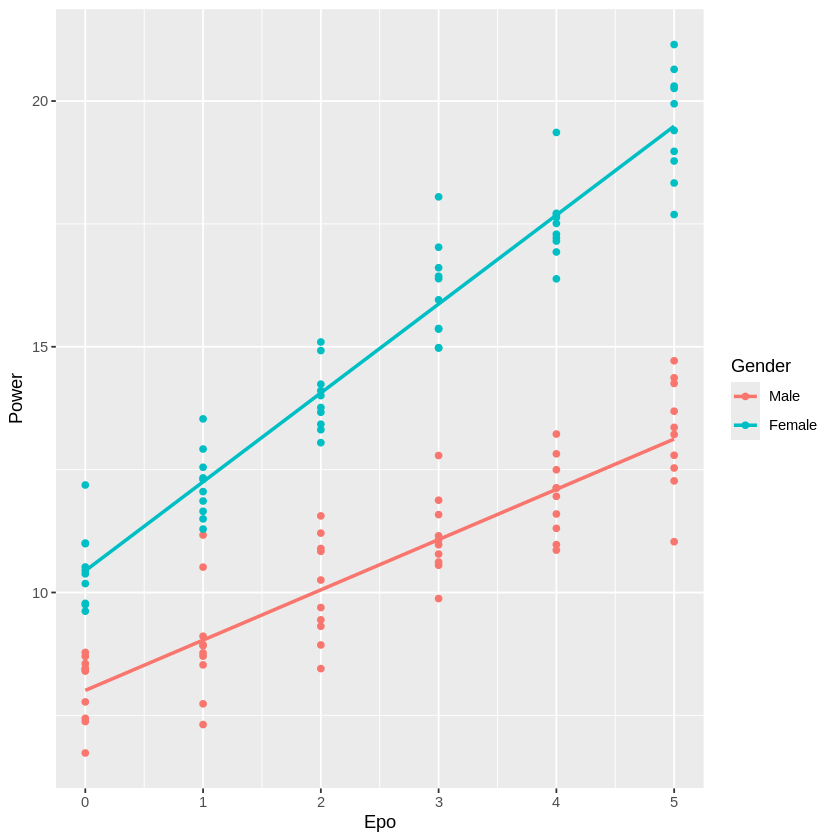

In [5]:
# Load ggplot2
library(ggplot2)

# Reproducibility
set.seed(123)

# Residuals
Residuals <- rnorm(length(Epo), 0, 1)

# Response variable
Power <- Gender_N + Gender_Int * Epo + Residuals

# Data frame
RANCOVA1b <- data.frame(Power, Gender, Epo, Subject)

# Plot
ggplot(RANCOVA1b, aes(x = Epo, y = Power, colour = Gender)) +
  geom_smooth(method = "lm", se = FALSE) +
  geom_point()


📊 Interpretation

* Variability added
* Still no subject-level variation
* This is standard ANCOVA

#### 📌 PART 5: RANDOM EFFECT ON INTERCEPT

`geom_smooth()` using formula = 'y ~ x'


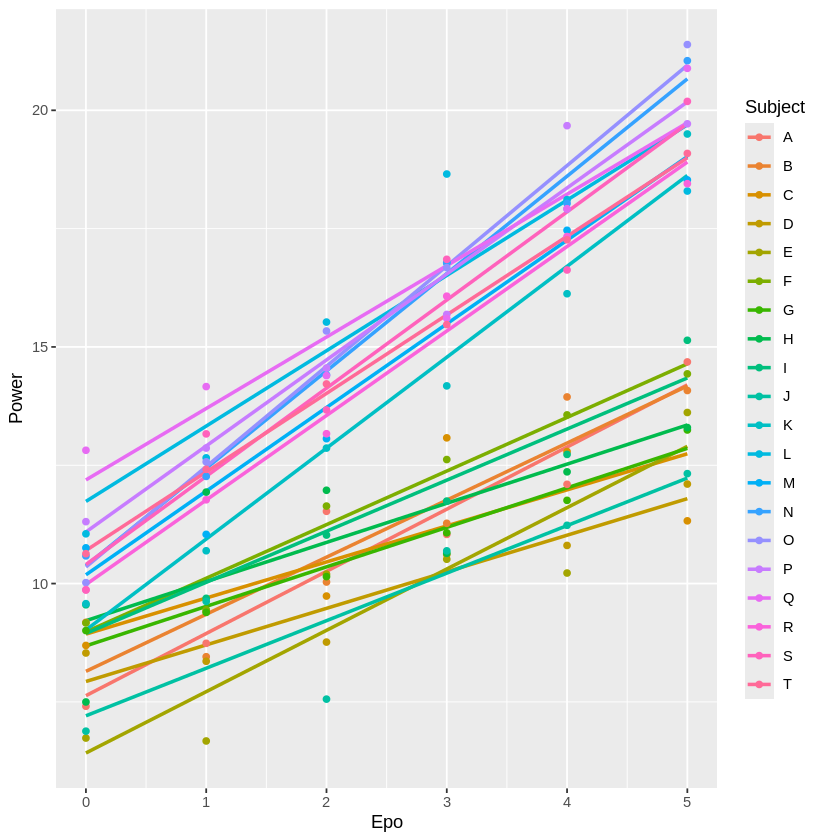

In [6]:
# Load ggplot2
library(ggplot2)

# Define model components
Intercept <- Gender_N + Random_Ef
Slope <- Gender_Int

# Reproducibility
set.seed(123)
Residuals <- rnorm(length(Epo), 0, 1)

# Response variable
Power <- Intercept + Slope * Epo + Residuals

# Data frame
RANCOVA1c <- data.frame(Power, Gender, Epo, Subject)

# Plot
ggplot(RANCOVA1c, aes(x = Epo, y = Power, colour = Subject)) +
  geom_smooth(method = "lm", se = FALSE) +
  geom_point()


📊 Interpretation

* Each subject has its own intercept
* Slopes are parallel
* Model: $Y_{ij​} = (β_0​ + u_{0j}​) + β_1 ​Epo + ε_{ij}$​

where

$u_{0j} ∼ N(0, σ_u^2)$



#### Plotting the Fixed Effect (Population Mean Behaviour)
To visualize:

* Individual subject regression lines (random effects)
* Overall fixed-effect regression lines (mean behaviour across subjects)

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
`geom_smooth()` using formula = 'y ~ x'


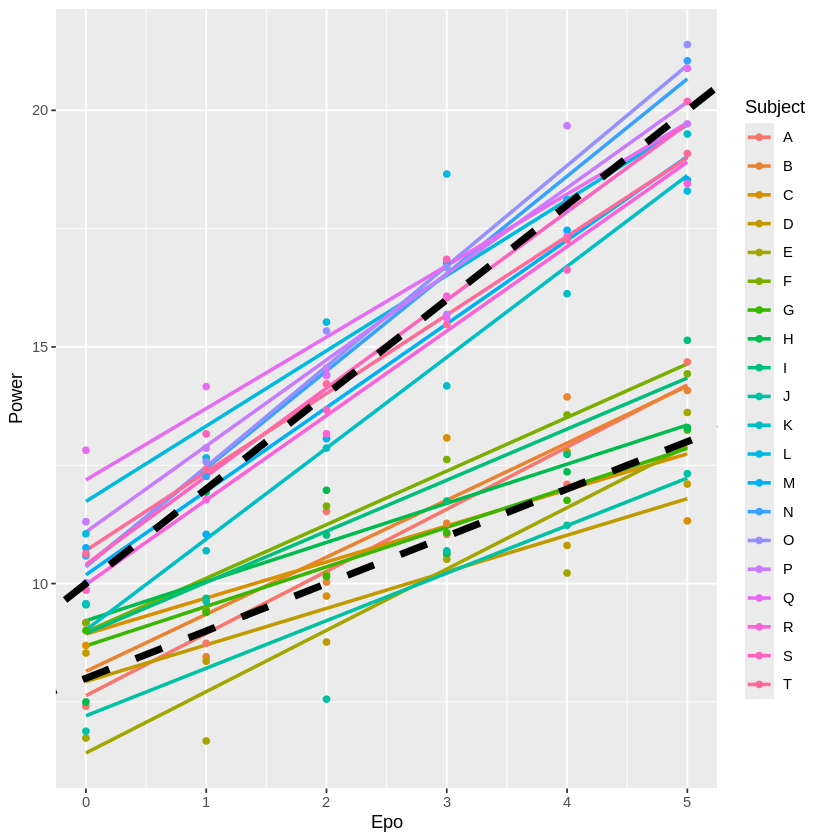

In [7]:
# Plot individual subject regression lines
# colour = Subject → each subject has its own line
# geom_smooth(method = "lm") → fits linear regression per subject
# se = FALSE → removes confidence band

ggplot(RANCOVA1c, aes(Epo, Power, colour = Subject)) +
  geom_smooth(method = "lm", se = FALSE) +   # Subject-specific regression lines
  geom_point() +                            # Raw data points

  # Add fixed-effect regression line for Males
  # intercept = 8, slope = 1 (population-level effect)
  geom_abline(intercept = 8, slope = 1,
              size = 2, lty = 2) +

  # Add fixed-effect regression line for Females
  # intercept = 10, slope = 2 (population-level effect)
  geom_abline(intercept = 10, slope = 2,
              size = 2, lty = 2)


📊 Statistical Interpretation

🔹 Solid Thin Lines

→ Subject-specific regression lines

→ Represent:  $(β_0​ + u_{0j}​) + β_1 ​Epo$

Each subject has:
* Different intercept (random effect)
* Same slope (because only random intercept was simulated)

🔹 Thick Dashed Lines

→ Fixed-effect (population-average) regression lines

For:
* Male: $Power = 8 + 1×Epo$
* Female:  $Power = 10 + 2×Epo$

These represent the mean trend across all subjects.

#### Intepretation:

✔ Mixed models separate:

* Population-level effects (fixed effects)
* Subject-level deviations (random effects)

✔ Random intercept model implies:

* Parallel subject lines
* Same slope
* Different starting points

✔ The dashed lines represent: $E(Y∣Epo,Gender)$

Mean response across subjects.

Model (Random Intercept)

$Y_{ij​} = (β_0​ + u_{0j}​) + β_1 ​Epo + ε_{ij}$​

where

$u_{0j} ∼ N(0, σ_u^2)$

$ε_{ij} ∼ N(0,σ^2)$

## 📌 ANALYSIS USING lme4

In [9]:
# Install lme4 if not already installed
# install.packages("lme4")

In [12]:
# Random intercept + slope model
Model1 <- lmer(Power ~ Gender * Epo + (1 + Epo | Subject))

# Random slope only
Model1b <- lmer(Power ~ Gender * Epo + (0 + Epo | Subject))

# Random intercept only
Model1c <- lmer(Power ~ Gender * Epo + (1 | Subject))

# Compare models
anova(Model1, Model1b)
anova(Model1, Model1c)

boundary (singular) fit: see help('isSingular')

refitting model(s) with ML (instead of REML)



,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Model1b,6,358.8049,375.5298,-173.4024,346.8049,NA,NA,NA
Model1,8,350.6662,372.9661,-167.3331,334.6662,12.1387,2,0.002312676


refitting model(s) with ML (instead of REML)



,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Model1c,6,346.6807,363.4057,-167.3404,334.6807,NA,NA,NA
Model1,8,350.6662,372.9661,-167.3331,334.6662,0.01455911,2,0.9927469


In [13]:
# Inspect summary
summary(Model1c)

Linear mixed model fit by REML ['lmerMod']
Formula: Power ~ Gender * Epo + (1 | Subject)

REML criterion at convergence: 344.1

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.3282 -0.6067 -0.1341  0.6257  2.6177 

Random effects:
 Groups   Name        Variance Std.Dev.
 Subject  (Intercept) 0.4102   0.6405  
 Residual             0.7770   0.8815  
Number of obs: 120, groups:  Subject, 20

Fixed effects:
                 Estimate Std. Error t value
(Intercept)       8.20963    0.28586  28.719
GenderFemale      2.39386    0.40427   5.921
Epo               1.02282    0.06663  15.350
GenderFemale:Epo  0.78631    0.09423   8.344

Correlation of Fixed Effects:
            (Intr) GndrFm Epo   
GenderFemal -0.707              
Epo         -0.583  0.412       
GendrFml:Ep  0.412 -0.583 -0.707

📊 Interpretation

* Only intercept variance significant
* Slope variance ≈ 0
* Estimated SD close to simulated value (≈ 0.5)

✔ Model correctly recovers simulation structure.

####  🔹 Visualizing Random Effects in a Mixed Model
Installing and Using lattice to Plot Random Effects

$Subject


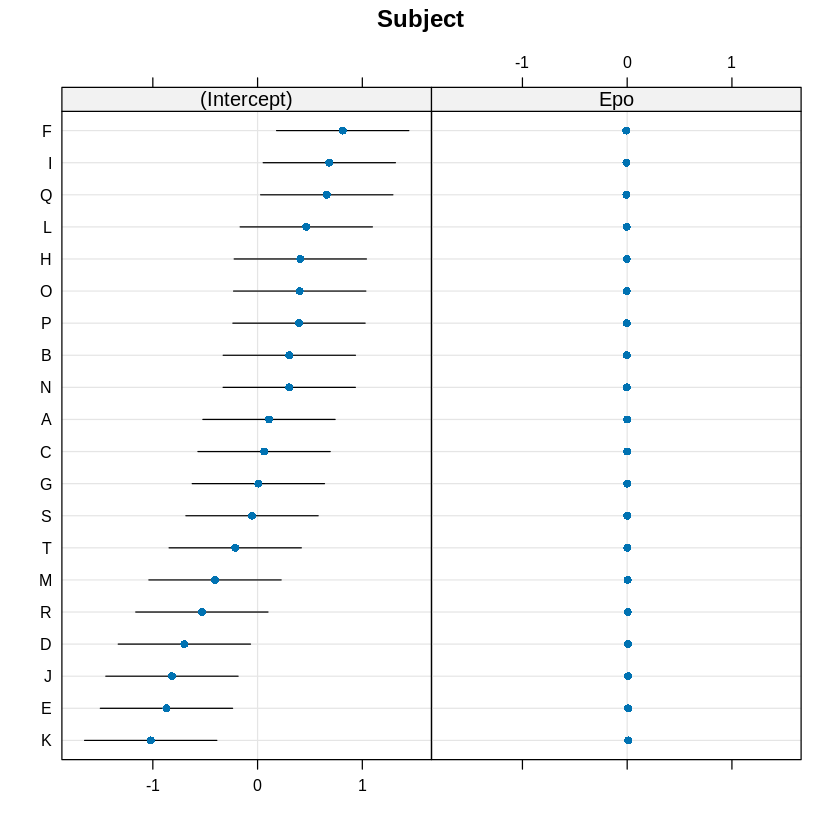

In [14]:
# Install the lattice package (Run this ONLY once)
# install.packages("lattice")

# Load lattice (only once per session)
library(lattice)

# Dotplot of random effects from Model1
dotplot(ranef(Model1, condVar = TRUE))

The plot displays:

* Estimated random intercepts for each Subject
* Estimated random slopes (if included in model)
* Confidence intervals around each estimate

#### 📌 PART 6: RANDOM EFFECT ON SLOPE ONLY

`geom_smooth()` using formula = 'y ~ x'


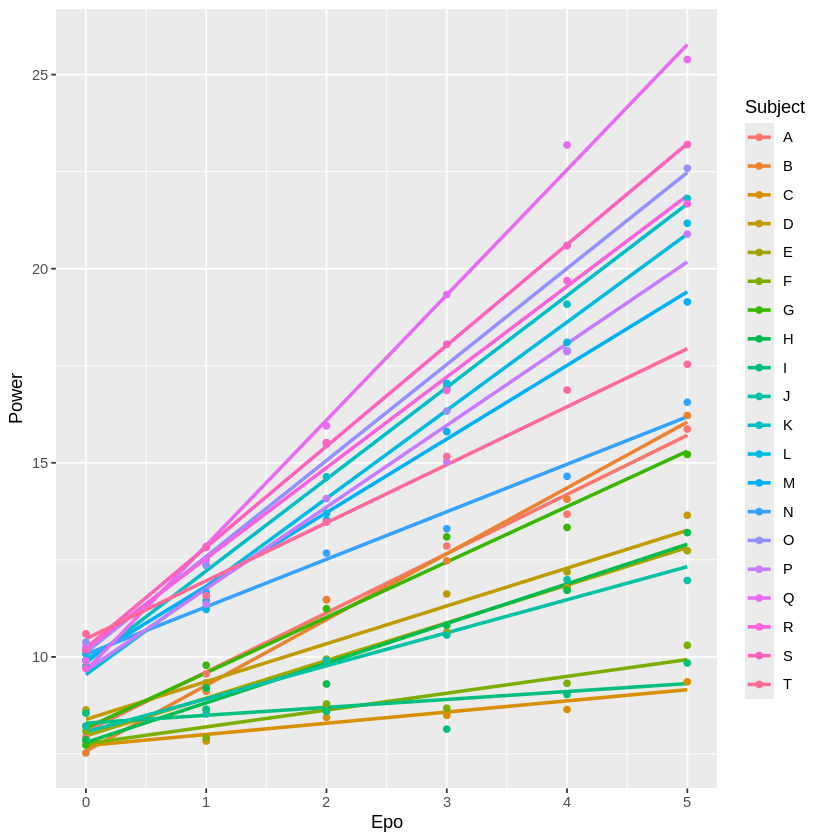

In [15]:
# Step 1: Load required package
library(ggplot2)

# Step 2: Set seed for reproducibility
set.seed(648)

# Step 3: Define random slopes (20 subjects, each with 6 observations)
Random_Ef_Slope <- rep(rnorm(20, mean = 0, sd = 0.5), each = 6)

# Step 4: Define intercept and slope components
Intercept <- Gender_N
Slope <- Gender_Int + Random_Ef_Slope

# Step 5: Add residual error
Residuals <- rnorm(length(Epo), mean = 0, sd = 0.5)

# Step 6: Construct response variable
Power <- Intercept + Slope * Epo + Residuals

# Step 7: Build data frame
RANCOVA2 <- data.frame(Power, Gender, Epo, Subject)

# Step 8: Plot regression lines per subject
ggplot(RANCOVA2, aes(x = Epo, y = Power, colour = Subject)) +
  geom_smooth(method = "lm", se = FALSE) +
  geom_point()


📊 Interpretation

* Intercepts identical
* Slopes vary by subject
* Lines fan out

##### Mixed model:

In [16]:
# Fit the mixed-effects model
Model2 <- lmer(Power ~ Gender * Epo + (1 + Epo | Subject),
               data = RANCOVA2)

# Inspect model summary
summary(Model2)


Linear mixed model fit by REML ['lmerMod']
Formula: Power ~ Gender * Epo + (1 + Epo | Subject)
   Data: RANCOVA2

REML criterion at convergence: 228.7

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.73280 -0.56197  0.00071  0.65225  1.93852 

Random effects:
 Groups   Name        Variance Std.Dev. Corr 
 Subject  (Intercept) 0.001183 0.03439       
          Epo         0.283944 0.53286  -1.00
 Residual             0.180063 0.42434       
Number of obs: 120, groups:  Subject, 20

Fixed effects:
                 Estimate Std. Error t value
(Intercept)       7.98075    0.09772  81.666
GenderFemale      1.98879    0.13820  14.390
Epo               0.93907    0.17153   5.475
GenderFemale:Epo  1.25971    0.24258   5.193

Correlation of Fixed Effects:
            (Intr) GndrFm Epo   
GenderFemal -0.707              
Epo         -0.263  0.186       
GendrFml:Ep  0.186 -0.263 -0.707

✔ Only slope variance significant.


####  🔹 Visualizing Random Effects in a Mixed Model

$Subject


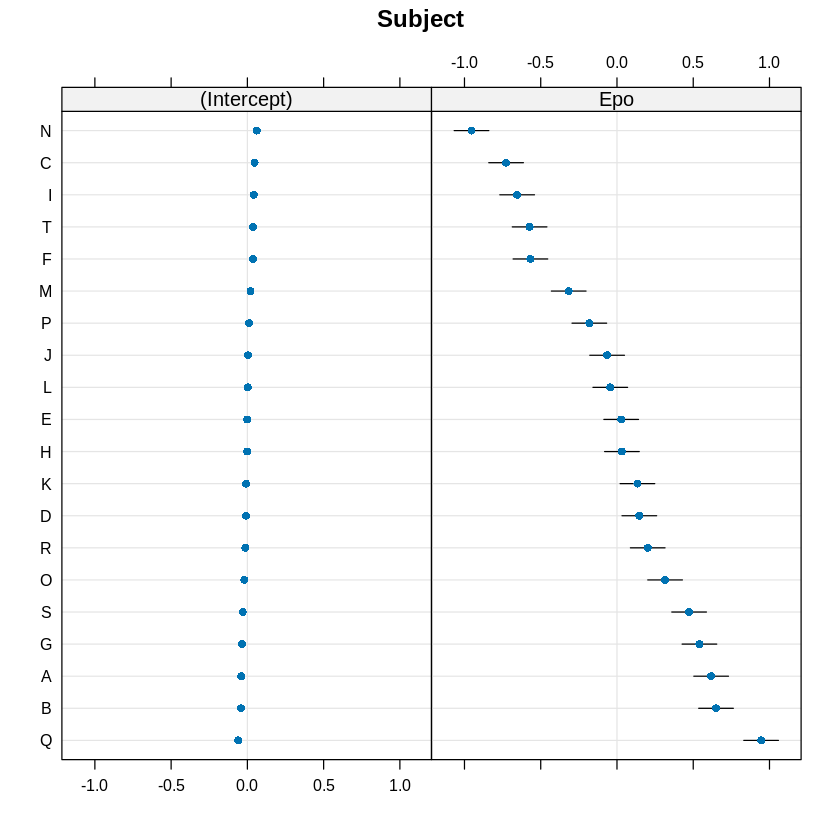

In [17]:
# Install the lattice package (Run this ONLY once)
# install.packages("lattice")

# Load required packages
library(lme4)   # for lmer()

# Fit your mixed-effects model (example)
Model2 <- lmer(Power ~ Gender * Epo + (1 + Epo | Subject),
               data = RANCOVA2)

# Visualize random effects
dotplot(ranef(Model2, condVar = TRUE))


### Mixed Model: Random Effect on Slope Only
To verify that Subject affects only the slope (as specified in the data simulation).

🔹 Step 1: Fit Full Random Intercept + Slope Model

In [18]:
# Full mixed model:
# Fixed effects: Gender, Epo, Gender×Epo
# Random effects: Intercept and Slope for Subject

Model2 <- lmer(Power ~ Gender * Epo + (1 + Epo | Subject),
               REML = FALSE,
               data = RANCOVA2)


boundary (singular) fit: see help('isSingular')



Meaning:
* One variance component is estimated ≈ 0
* Likely the random intercept variance
* Indicates model over-parameterization

🔹 Step 2: Fit Random Slope Only Model

In [19]:
# Random slope only (no random intercept)

Model2b <- lmer(Power ~ Gender * Epo + (0 + Epo | Subject),
                REML = FALSE,
                data = RANCOVA2)


This matches the data-generating process.

🔹 Step 3: Fit Random Intercept Only Model

In [20]:
# Random intercept only model

Model2c <- lmer(Power ~ Gender * Epo + (1 | Subject),
                REML = FALSE,
                data = RANCOVA2)


🔹 Step 4: Compare Models Using Likelihood Ratio Test

In [21]:
# Compare full vs random slope only
anova(Model2, Model2b)

# Compare full vs random intercept only
anova(Model2, Model2c)


,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Model2b,6,231.6974,248.4224,-109.8487,219.6974,NA,NA,NA
Model2,8,235.4700,257.7699,-109.7350,219.4700,0.2274679,2,0.8924954


,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Model2c,6,404.0397,420.7647,-196.0199,392.0397,NA,NA,NA
Model2,8,235.4700,257.7699,-109.7350,219.4700,172.5697,2,3.364805e-38


Interpretation of Model Comparisons

* If Model2b ≈ Model2 → intercept variance ≈ 0
* If Model2 significantly better than Model2c → slope variance important

🔹 Step 5: Examine Final Model Output

In [23]:
# Inspect model summary
summary(Model2)


Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: Power ~ Gender * Epo + (1 + Epo | Subject)
   Data: RANCOVA2

      AIC       BIC    logLik -2*log(L)  df.resid 
    235.5     257.8    -109.7     219.5       112 

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.75819 -0.56030 -0.00094  0.65806  1.95592 

Random effects:
 Groups   Name        Variance Std.Dev. Corr 
 Subject  (Intercept) 0.001063 0.0326        
          Epo         0.255257 0.5052   -1.00
 Residual             0.176464 0.4201        
Number of obs: 120, groups:  Subject, 20

Fixed effects:
                 Estimate Std. Error t value
(Intercept)       7.98075    0.09669  82.537
GenderFemale      1.98879    0.13675  14.544
Epo               0.93907    0.16289   5.765
GenderFemale:Epo  1.25971    0.23037   5.468

Correlation of Fixed Effects:
            (Intr) GndrFm Epo   
GenderFemal -0.707              
Epo         -0.265  0.187       
GendrFml:Ep  0.187 -0.265 -0.707
optimizer (

Interpretation

Since the data were simulated as:

$Slope = Gender_Int + u_{1j}$

and

$Intercept=Gender_N$​

We expect:

✔ Significant random slope variance

✖ Random intercept variance ≈ 0

✔ Singular fit warning in full model

#### 🎓 Conclusion

We only observe an effect of Subject on the slope, as specified by the data-generating model.

#### 📌 PART 7: RANDOM INTERCEPT & SLOPE (NEGATIVE CORRELATION)

`geom_smooth()` using formula = 'y ~ x'


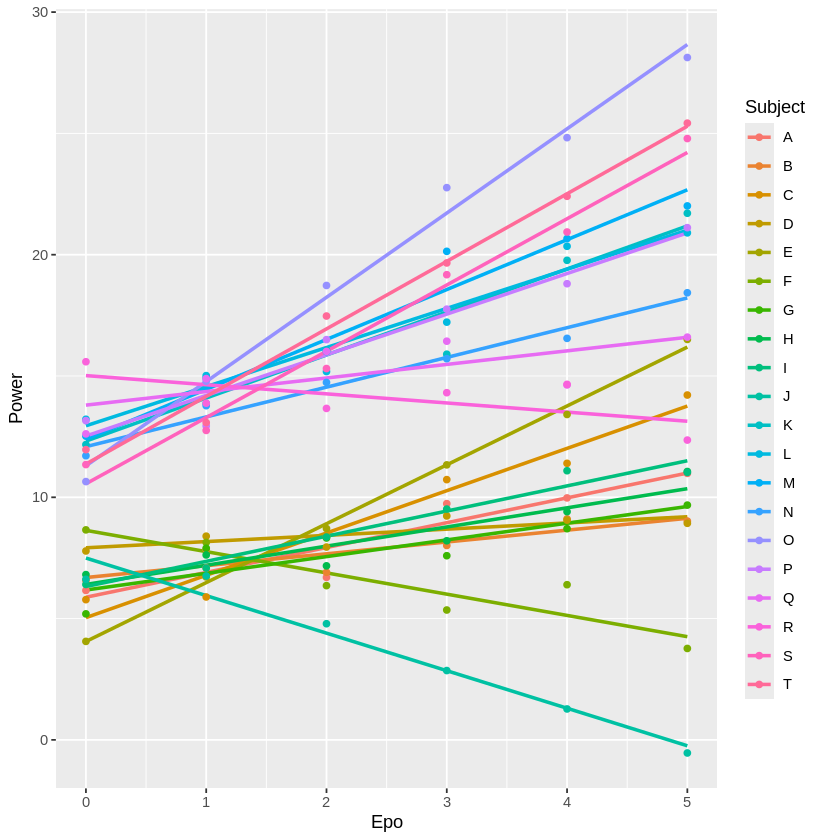

In [24]:
# Load required package
library(ggplot2)

# Set seed for reproducibility
set.seed(354)

# Define random intercepts and slopes for 20 subjects, 6 observations each
Random_Ef_Int   <- round(rep(rnorm(20, mean = 0, sd = 1), each = 6), 2)
Random_Ef_Slope <- -Random_Ef_Int +
                   round(rep(rnorm(20, mean = 0, sd = 0.4), each = 6), 2)

# Define fixed effects (example: two gender groups with different baselines)
Gender_N <- rep(c(6, 12), each = 60)

Intercept <- Gender_N + Random_Ef_Int
Slope     <- Gender_Int + Random_Ef_Slope

# Add residual error
Residuals <- rnorm(length(Epo), mean = 0, sd = 0.8)

# Construct response variable
Power <- Intercept + Slope * Epo + Residuals

# Build data frame
RANCOVA3 <- data.frame(Power, Gender, Epo, Subject)

# Plot regression lines per subject
ggplot(RANCOVA3, aes(x = Epo, y = Power, colour = Subject)) +
  geom_smooth(method = "lm", se = FALSE) +
  geom_point()


📊 Interpretation

* Subjects with high intercept → lower slope
* Negative correlation between random effects

Model:

In [25]:
# Fit the mixed-effects model
Model3 <- lmer(Power ~ Gender * Epo + (1 + Epo | Subject),
               data = RANCOVA3)

# Inspect model summary
summary(Model3)

Linear mixed model fit by REML ['lmerMod']
Formula: Power ~ Gender * Epo + (1 + Epo | Subject)
   Data: RANCOVA3

REML criterion at convergence: 371

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.33362 -0.58321 -0.01178  0.69029  2.17433 

Random effects:
 Groups   Name        Variance Std.Dev. Corr 
 Subject  (Intercept) 1.4300   1.1958        
          Epo         1.2631   1.1239   -0.94
 Residual             0.5694   0.7546        
Number of obs: 120, groups:  Subject, 20

Fixed effects:
                 Estimate Std. Error t value
(Intercept)        6.4621     0.4157  15.544
GenderFemale       5.9689     0.5879  10.152
Epo                0.6030     0.3599   1.675
GenderFemale:Epo   1.1487     0.5090   2.257

Correlation of Fixed Effects:
            (Intr) GndrFm Epo   
GenderFemal -0.707              
Epo         -0.900  0.637       
GendrFml:Ep  0.637 -0.900 -0.707

✔ Correlation term estimated negative.

####  🔹 Visualizing Random Effects in a Mixed Model

$Subject


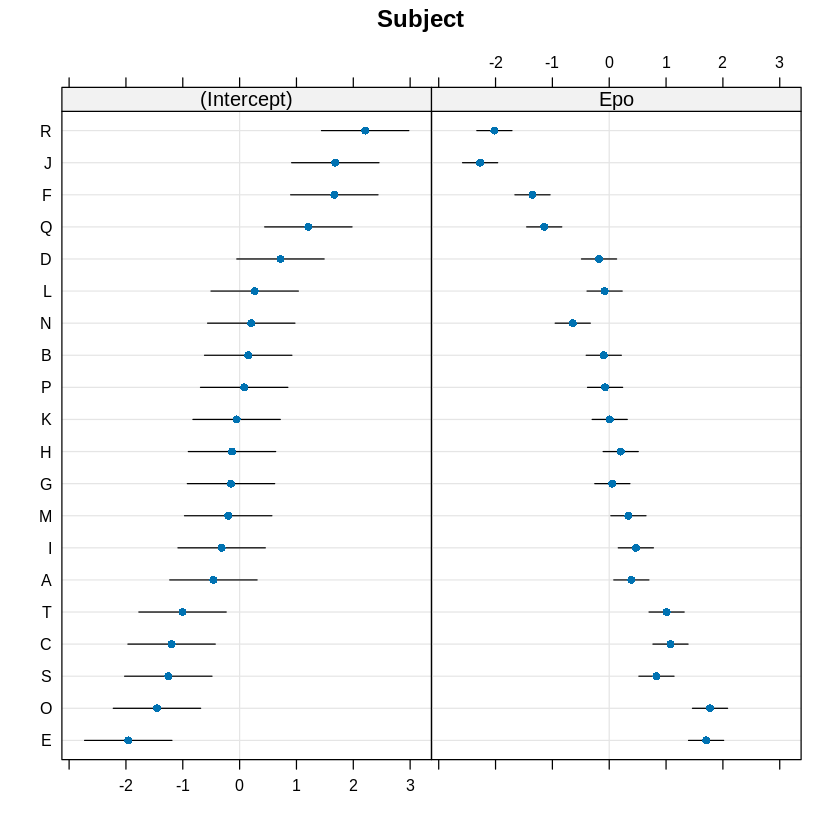

In [26]:
# Install required packages (run once if not already installed)
# install.packages("lme4")

# Load packages
library(lme4)

# Visualize random effects
dotplot(ranef(Model3, condVar = TRUE))


####📌 PART 8: RANDOM INTERCEPT & SLOPE (NO CORRELATION)

`geom_smooth()` using formula = 'y ~ x'


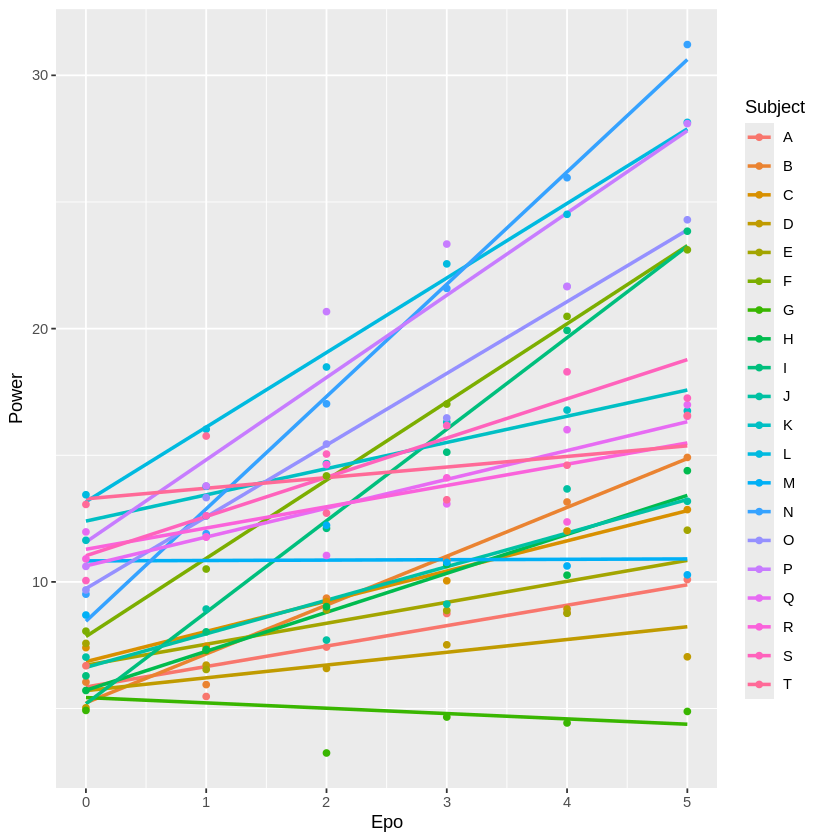

In [27]:
# Step 1: Load required package
library(ggplot2)

# Step 2: Set seed for reproducibility
set.seed(625)

# Step 3: Define random intercepts and slopes for 20 subjects, 6 observations each
Random_Ef_Int   <- rep(rnorm(20, mean = 0, sd = 0.8), each = 6)
Random_Ef_Slope <- rep(rnorm(20, mean = 0, sd = 1.5), each = 6)

# Step 4: Define fixed effects
Intercept <- Gender_N - Random_Ef_Int
Slope     <- Gender_Int + Random_Ef_Slope

# Step 5: Add residual error
Residuals <- rnorm(length(Epo), mean = 0, sd = 1.2)

# Step 6: Construct response variable
Power <- Intercept + Slope * Epo + Residuals

# Step 7: Build data frame
RANCOVA4 <- data.frame(Power, Gender, Epo, Subject)

# Step 8: Plot regression lines per subject
ggplot(RANCOVA4, aes(x = Epo, y = Power, colour = Subject)) +
  geom_smooth(method = "lm", se = FALSE) +
  geom_point()


Analysis of data:

In [28]:
# Fit the mixed-effects model
Model4 <- lmer(Power ~ Gender * Epo + (1 + Epo | Subject),
               data = RANCOVA4)

# Inspect model summary
summary(Model4)


Linear mixed model fit by REML ['lmerMod']
Formula: Power ~ Gender * Epo + (1 + Epo | Subject)
   Data: RANCOVA4

REML criterion at convergence: 473.5

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.39354 -0.46291  0.05095  0.59931  2.35255 

Random effects:
 Groups   Name        Variance Std.Dev. Corr 
 Subject  (Intercept) 0.7488   0.8653        
          Epo         1.6217   1.2735   -0.19
 Residual             1.3945   1.1809        
Number of obs: 120, groups:  Subject, 20

Fixed effects:
                 Estimate Std. Error t value
(Intercept)        6.1164     0.3846  15.903
GenderFemale       5.1226     0.5439   9.418
Epo                1.4614     0.4125   3.543
GenderFemale:Epo   0.3840     0.5833   0.658

Correlation of Fixed Effects:
            (Intr) GndrFm Epo   
GenderFemal -0.707              
Epo         -0.258  0.182       
GendrFml:Ep  0.182 -0.258 -0.707

####  🔹 Visualizing Random Effects in a Mixed Model

$Subject


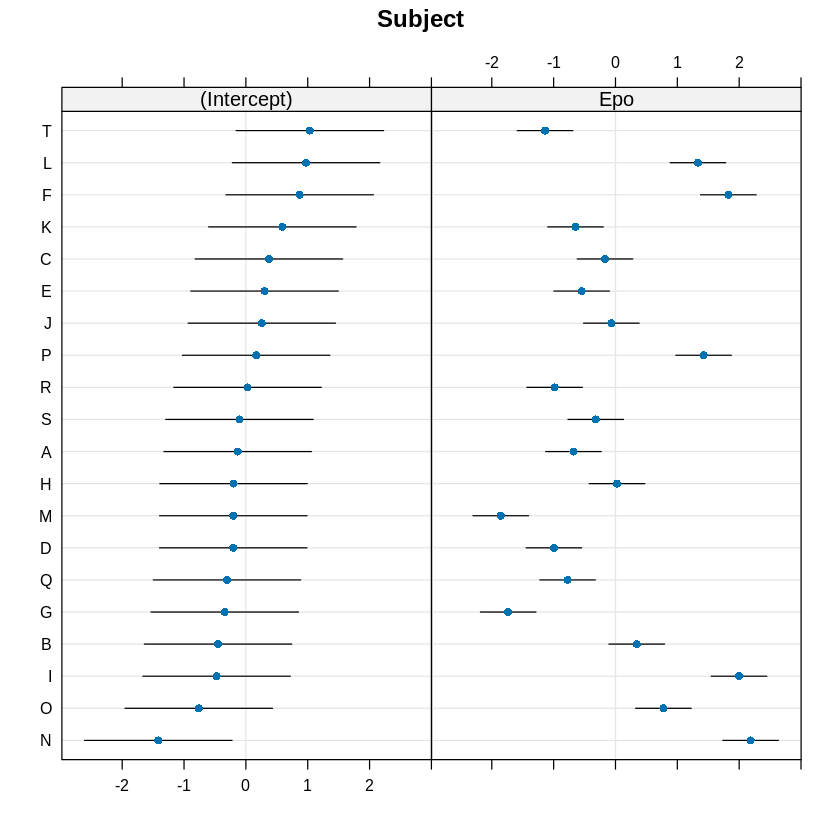

In [29]:
# Load packages
library(lme4)

# Visualize random effects
dotplot(ranef(Model4, condVar = TRUE))

📊 Interpretation

* Both intercept and slope variance significant
* Correlation ≈ 0
* Model recovers independent random effects

#### 📌 FINAL SUMMARY

| Model Type          | Intercept Variance | Slope Variance  | Correlation |
| ------------------- | ------------------ | --------------  | ----------- |
| Fixed ANCOVA        | ❌                 | ❌             | —           |
| Random Intercept    | ✔                  | ❌             | —           |
| Random Slope        | ❌                 | ✔              | —           |
| Both + Correlation  | ✔                  | ✔              | ±           |
| Both No Correlation | ✔                  | ✔              | 0           |


<div class="alert alert-block alert-info" style="margin-top: 20px">
    
### THANK YOU ...! 

__Ms.MRUNALINI (Data Science Trainer)__
📧 mrunalini0107@gmail.com
📍 Mumbai–400095